<div style="margin-bottom: 32px;">
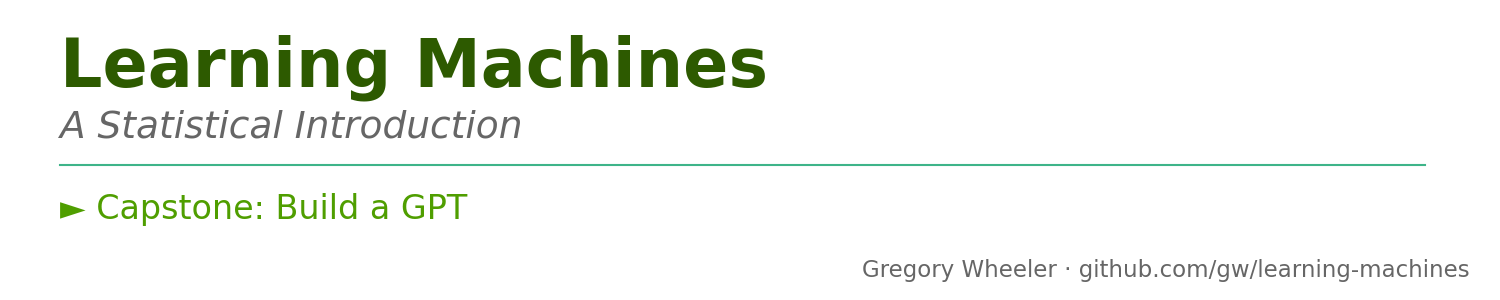
</div>


# Capstone — Build a GPT

This capstone assembles the transformer of Chapter 11 into a small but complete **character-level language model** and trains it with the next-token objective of Chapter 12. You will write each piece you have read about—an attention head, multi-head attention, a transformer block, the next-token training loop, and autoregressive generation—and watch a model of about a third of a million parameters learn to produce (rough) Shakespeare on a laptop.

Three cells are marked **🔧 Your turn**: a working reference follows each, so the notebook still runs end to end, but try writing them yourself first—they are exactly the results you derived in the Chapter 11 and 12 exercises.

The step-by-step structure follows Andrej Karpathy's *"Let's build GPT: from scratch"* lecture and his [nanoGPT](https://github.com/karpathy/nanoGPT); the code here is our own, in this book's notation. For real tokenization and GPT-2-scale weights, nanoGPT is where to go next.

In [1]:
import os, math, urllib.request
import torch
import torch.nn as nn
from torch.nn import functional as F
import matplotlib.pyplot as plt
# Colab: fetch the plot-style helper if it isn't beside this notebook
import os as _os, urllib.request as _ur
if not _os.path.exists("mlone_theme.py"):
    _BASE = "https://raw.githubusercontent.com/welr/learning_machines/main/"
    for _f in ("mlone_theme.py", "mlone_style.mplstyle"):
        _ur.urlretrieve(_BASE + _f, _f)
import mlone_theme as mt

plt.style.use("mlone_style.mplstyle")
mt.set_notebook_mode()                       # green companion-notebook palette
torch.manual_seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"   # use "mps" on Apple Silicon if you prefer
print("device:", device)

device: cpu


## The data: characters in, characters out

Real language models tokenize text into sub-word pieces (Chapter 12); here we keep things as simple as possible and work **character by character**, so the "vocabulary" is just the set of distinct characters in the text. The corpus is Karpathy's *Tiny Shakespeare*—about a megabyte of the plays, concatenated.

Encoding maps each character to an integer; decoding maps back. `get_batch` draws a batch of random `block_size`-length windows, with the targets shifted one position right: at every position the model is asked to predict the next character.

In [2]:
DATA_URL = "https://raw.githubusercontent.com/karpathy/ng-video-lecture/master/input.txt"
if not os.path.exists("input.txt"):
    urllib.request.urlretrieve(DATA_URL, "input.txt")
text = open("input.txt").read()

chars = sorted(set(text))
vocab_size = len(chars)
stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for ch, i in stoi.items()}
encode = lambda s: [stoi[c] for c in s]
decode = lambda ids: "".join(itos[i] for i in ids)

data = torch.tensor(encode(text), dtype=torch.long)
n_train = int(0.9 * len(data))
train_data, val_data = data[:n_train], data[n_train:]

print(f"{len(text):,} characters, vocabulary of {vocab_size}")

def get_batch(split):
    d = train_data if split == "train" else val_data
    ix = torch.randint(len(d) - block_size, (batch_size,))
    x = torch.stack([d[i : i + block_size] for i in ix])
    y = torch.stack([d[i + 1 : i + block_size + 1] for i in ix])
    return x.to(device), y.to(device)

1,115,394 characters, vocabulary of 65


## Configuration

These are deliberately small, so the model trains in a couple of minutes on a CPU. They are also the only knobs separating this from a serious model: Chapter 12's scaling laws say that growing `n_embd`, `n_layer`, and the data *together* drives the loss down predictably. The full lecture configuration (`n_embd=384, n_layer=6, block_size=256`) wants a GPU; see the closing note.

In [3]:
batch_size    = 32      # sequences per batch
block_size    = 64      # context length (characters of history the model sees)
n_embd        = 96      # embedding / model width
n_head        = 4       # attention heads per block
n_layer       = 3       # transformer blocks
dropout       = 0.1
learning_rate = 1e-3
max_iters     = 3000
eval_interval = 300
eval_iters    = 100

## One attention head

A single head of self-attention is the computation at the heart of Chapter 11: project each position to a **query**, **key**, and **value**; score every query against every key; scale by $\sqrt{d_k}$ to keep the softmax out of saturation (Exercise 11.3); mask out the future so position $t$ cannot see positions after it (the causal mask); softmax into weights; and return the weighted sum of the values.

**🔧 Your turn.** Implement `Head.forward`. You showed in Exercise 11.9 that its output is a convex combination of the value vectors—nonnegative weights summing to one. A reference implementation follows; try it before reading ours.

In [4]:
class Head(nn.Module):
    """One head of causal self-attention."""
    def __init__(self, head_size):
        super().__init__()
        self.key   = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        # lower-triangular mask, stored as a buffer (not a learned parameter)
        self.register_buffer("tril", torch.tril(torch.ones(block_size, block_size)))
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        B, T, C = x.shape
        k = self.key(x)                                          # (B, T, head_size)
        q = self.query(x)
        # scaled dot-product scores; 1/sqrt(d_k) keeps their variance near 1 (Exercise 11.3)
        weights = q @ k.transpose(-2, -1) * k.shape[-1] ** -0.5  # (B, T, T)
        # causal mask: a position may attend only to itself and the past
        weights = weights.masked_fill(self.tril[:T, :T] == 0, float("-inf"))
        weights = F.softmax(weights, dim=-1)                     # each row is a probability vector
        weights = self.dropout(weights)
        return weights @ self.value(x)                           # (B, T, head_size)

## Many heads, in parallel — and the feed-forward

One head learns one kind of relationship. **Multi-head attention** runs several in parallel—each in a slice of the model width, so the total cost matches a single full-width head (Exercise 11.7)—and concatenates their outputs before a final projection. We keep the heads in an explicit `ModuleList` rather than batching them, because here clarity matters more than speed. Each block also carries a **position-wise feed-forward** network: the same small MLP applied independently at every position.

In [5]:
class MultiHeadAttention(nn.Module):
    """Several attention heads run in parallel, then concatenated and projected."""
    def __init__(self, num_heads, head_size):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])
        self.proj = nn.Linear(num_heads * head_size, n_embd)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        return self.dropout(self.proj(out))

In [6]:
class FeedForward(nn.Module):
    """Position-wise MLP: expand to 4x width, a nonlinearity, then project back."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.ReLU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)

## A transformer block

A block is attention followed by the feed-forward network, each wrapped in the two devices that make deep transformers trainable (Chapter 11): a **residual connection** (add the input back to the output) and **layer normalization** applied before each sublayer.

**🔧 Your turn.** Write `Block.forward` so that it computes `x + attention(norm(x))` and then `x + feedforward(norm(x))`. The residual "+ x" is the gradient highway of Exercise 9.9. Reference below.

In [7]:
class Block(nn.Module):
    """A transformer block: pre-norm attention and feed-forward, each with a residual."""
    def __init__(self, n_embd, n_head):
        super().__init__()
        head_size = n_embd // n_head
        self.attn = MultiHeadAttention(n_head, head_size)
        self.ffwd = FeedForward()
        self.norm1 = nn.LayerNorm(n_embd)
        self.norm2 = nn.LayerNorm(n_embd)

    def forward(self, x):
        x = x + self.attn(self.norm1(x))     # residual around attention
        x = x + self.ffwd(self.norm2(x))     # residual around feed-forward
        return x

## The full model

The language model strings it together: a **token embedding** and a **position embedding** (Chapter 11's "from tokens to vectors," plus the order information attention otherwise lacks), a stack of blocks, a final layer norm, and a linear head mapping each position to a score over the vocabulary. Given targets, `forward` returns the **cross-entropy loss**—the next-token objective of Chapter 12, identical in form to the softmax-regression loss of Chapter 4.

In [8]:
class GPTLanguageModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.token_embedding = nn.Embedding(vocab_size, n_embd)
        self.position_embedding = nn.Embedding(block_size, n_embd)
        self.blocks = nn.Sequential(*[Block(n_embd, n_head) for _ in range(n_layer)])
        self.norm_final = nn.LayerNorm(n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        tok = self.token_embedding(idx)                              # (B, T, n_embd)
        pos = self.position_embedding(torch.arange(T, device=idx.device))
        x = tok + pos
        x = self.norm_final(self.blocks(x))
        logits = self.lm_head(x)                                     # (B, T, vocab_size)
        if targets is None:
            return logits, None
        loss = F.cross_entropy(logits.view(B * T, vocab_size), targets.view(B * T))
        return logits, loss

model = GPTLanguageModel().to(device)
print(f"{sum(p.numel() for p in model.parameters()) / 1e3:.0f}k parameters")

354k parameters


## Training

We minimize the average next-token cross-entropy with AdamW, checking held-out loss periodically. Reported alongside the loss is the **perplexity** $\exp(\text{loss})$ of Chapter 12—the effective number of equally likely characters the model is choosing among at each step.

In [9]:
@torch.no_grad()
def estimate_loss():
    model.eval()
    out = {}
    for split in ("train", "val"):
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            _, loss = model(*get_batch(split))
            losses[k] = loss.item()
        out[split] = losses.mean().item()
    model.train()
    return out

optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)
history = []
for step in range(max_iters + 1):
    if step % eval_interval == 0:
        L = estimate_loss()
        history.append((step, L["train"], L["val"]))
        print(f"step {step:4d} | train {L['train']:.3f} | val {L['val']:.3f} | val perplexity {math.exp(L['val']):.2f}")
    x, y = get_batch("train")
    _, loss = model(x, y)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

step    0 | train 4.381 | val 4.367 | val perplexity 78.84


step  300 | train 2.293 | val 2.319 | val perplexity 10.17


step  600 | train 2.056 | val 2.099 | val perplexity 8.16


step  900 | train 1.908 | val 1.996 | val perplexity 7.36


step 1200 | train 1.803 | val 1.919 | val perplexity 6.81


...

step 1800 | train 1.685 | val 1.844 | val perplexity 6.32


step 2100 | train 1.653 | val 1.828 | val perplexity 6.22


step 2400 | train 1.610 | val 1.781 | val perplexity 5.94


step 2700 | train 1.596 | val 1.766 | val perplexity 5.85


step 3000 | train 1.576 | val 1.742 | val perplexity 5.71


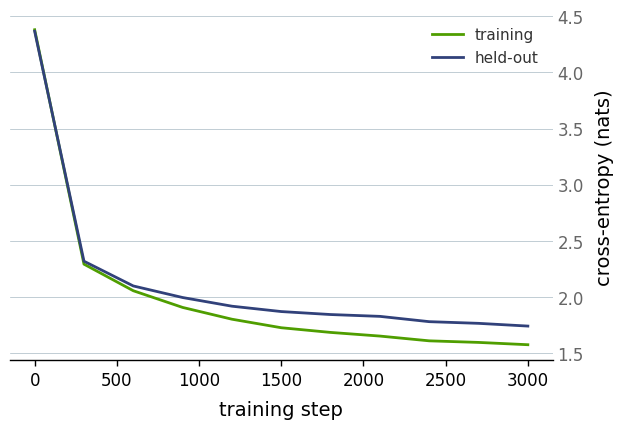

final held-out perplexity: 5.71


In [10]:
steps, tr, va = zip(*history)
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(steps, tr, color=mt.GREEN,   lw=2, label="training")
ax.plot(steps, va, color=mt.FS_BLUE, lw=2, label="held-out")
ax.set_xlabel("training step")
ax.set_ylabel("cross-entropy (nats)")
ax.legend()
mt.apply_book_style(ax)
plt.show()
print(f"final held-out perplexity: {math.exp(va[-1]):.2f}")

## Generating text

To generate, we run the model forward one character at a time: take the logits at the last position, turn them into a distribution, sample a character, append it, and repeat—**autoregressive decoding** (Chapter 12).

**🔧 Your turn.** Add the two decoding controls of Chapter 12: divide the logits by a **temperature** before the softmax (Exercise 12.5), and optionally keep only the **top-$k$** most probable characters (Exercise 12.9). Reference below.

In [11]:
@torch.no_grad()
def generate(model, idx, max_new_tokens, temperature=1.0, top_k=None):
    model.eval()
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -block_size:]                  # never look back further than the context
        logits, _ = model(idx_cond)
        logits = logits[:, -1, :] / temperature          # last step only; temperature sharpens/flattens
        if top_k is not None:
            v, _ = torch.topk(logits, top_k)
            logits[logits < v[:, [-1]]] = -float("inf")  # drop the long tail
        probs = F.softmax(logits, dim=-1)
        idx_next = torch.multinomial(probs, num_samples=1)
        idx = torch.cat([idx, idx_next], dim=1)
    model.train()
    return idx

In [12]:
context = torch.zeros((1, 1), dtype=torch.long, device=device)
for temp in (0.5, 0.8, 1.2):
    print(f"\n========== temperature {temp} ==========")
    print(decode(generate(model, context, 300, temperature=temp)[0].tolist()))


========== temperature 0.5 ==========




SICINIUS:
I will the gracious the cold noble be the knows my lord,
And the course the soon the brother for me.

KING RICHARD II:
Why, what for you how the king to made of his the veing the know
And be shall said that did to be king,
And he say of the be the made to be shall deep a good.

KING RICHA

========== temperature 0.8 ==========



And should me day a words, to thy is have seems
Say expul streick hearl chare could their with things,
One his bloody hath a sakest of way,
In a smay pleast ten in a for the can terrow-- blood,
Then forth to man my have took's death.

BRUTUS:
You tear me a may and mores, be if by your slate;
What, s

========== temperature 1.2 ==========




ARCALIO:
'Till
I take you by alt's faretch honisher:
Who you, good 'guild be that you in, you surfholl
And hoblen for gracition!
Come a queen, and yes from the renough
sent the himself
Wair'd to set great so comes knows.


CORTLLA:
How my brakel'd: in s; what two mUgbroke a geet
vert of bride; boya


## What did it learn?

A third of a million parameters, trained for a couple of minutes on a megabyte of text, is enough to learn the *shape* of the data: line breaks, speaker labels in capitals, the rhythm of the verse, plausible-looking words. It is not enough to be coherent—the model has no idea what it is saying. That gap is the subject of Chapter 12's scaling laws: the cross-entropy floor $E$ in $L(N,D)=E+A/N^\alpha+B/D^\beta$ lies far below where we are, and the way down is more parameters and more data, grown together. nanoGPT is the same architecture scaled up until the babble becomes fluent.

## Try next

- **A different corpus.** The cell below loads a public-domain economics text—Adam Smith's *Wealth of Nations*—as a character stream. Set `text = econ_text` and re-run the cells from "The data" onward; the model learns a very different voice. Notice how the vocabulary and sentence structure change what is easy to predict.
- **Real tokenization and scale.** Swap character-level encoding for byte-pair encoding and load pretrained GPT-2 weights with [nanoGPT](https://github.com/karpathy/nanoGPT); the architecture is exactly this one, batched and tuned for speed.
- **Alignment.** This model only predicts the next token. Chapter 12 describes how a second stage—reward modeling and a KL-penalized update (RLHF)—turns such a model into one that follows instructions. Sketch where in this pipeline that stage would attach.

In [13]:
def load_gutenberg(url, start_marker="*** START", end_marker="*** END"):
    """Download a Project Gutenberg plain-text book and strip its header/footer."""
    req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
    try:
        raw = urllib.request.urlopen(req, timeout=30).read().decode("utf-8", "replace")
    except Exception as e:
        print("download failed:", e)
        return None
    i, j = raw.find(start_marker), raw.rfind(end_marker)
    return raw[raw.find("\n", i) + 1 : j].strip() if i != -1 and j != -1 else raw

econ_text = load_gutenberg("https://www.gutenberg.org/cache/epub/3300/pg3300.txt")
if econ_text:
    print(f"Wealth of Nations: {len(econ_text):,} characters")
    print(econ_text[:280])
    # to train on it:  text = econ_text   then re-run from "The data" onward

Wealth of Nations: 2,447,787 characters
An Inquiry into the Nature and Causes of the Wealth of Nations

by Adam Smith




Contents


 INTRODUCTION AND PLAN OF THE WORK.

 BOOK I. OF THE CAUSES OF IMPROVEMENT IN THE PRODUCTIVE
POWERS OF LABOUR, AND OF THE ORDER ACCORDING TO WHICH ITS PRODUCE IS NATURALLY
D
